># Multitemporal Change Detection in the El Espinal, Tolima, Colombia

>## Hands-On Geoprocessing Project

>This project applies a cloud-native geospatial workflow using the Copernicus Data Space Ecosystem (CDSE), Sentinel-2 Level-2A imagery, Rasterio, Xarray, and Leafmap to perform multitemporal change detection in the rural area of El Espinal municipality, Tolima, Colombia.

>Two Sentinel-2 acquisitions from different dates will be selected and compared. The spectral data will be accessed directly from the Copernicus S3 object storage using GDAL's `/vsis3/` virtual file system, avoiding the download of complete Sentinel-2 products.

>The workflow includes:

>- Definition of the Area of Interest (AOI).
>- Query of Sentinel-2 L2A products using the CDSE OData API.
>- Selection of two acquisition dates.
>- Cloud-native access to spectral bands using `/vsis3/`.
>- Spatial clipping of both acquisitions to the AOI.
>- Generation of a multitemporal difference image.
>- Calculation of descriptive statistics and a histogram of pixel differences.
>- Interactive visualization using Leafmap.
>- Export of the final difference raster as a GeoTIFF in EPSG:9377 (MAGNA-SIRGAS 2018 / Origen-Nacional).

>## 1. Importing the Required Libraries

>The workflow requires libraries for numerical processing, geospatial vector and raster analysis, interaction with the Copernicus Data Space Ecosystem, coordinate transformations, visualization, and cloud-based S3 access.

>The libraries are imported at the beginning of the notebook to maintain a reproducible and organized workflow.

In [1]:
import os
import json
import requests
import boto3
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import rasterio
import xarray as xr
import rioxarray

from shapely.geometry import box, shape, mapping
from rasterio.mask import mask
from rasterio.session import AWSSession
from rasterio.warp import (
    calculate_default_transform,
    reproject,
    Resampling
)

print("Libraries imported successfully.")

Libraries imported successfully.


>## 2. Area of Interest (AOI)

>The study area corresponds to the rural area of El Espinal municipality, located in the department of Tolima, Colombia.

>Instead of defining the study area only from a geographic point or an arbitrary bounding box, a vector polygon will be used to represent the Area of Interest (AOI). This allows the Sentinel-2 imagery from both acquisition dates to be clipped using exactly the same spatial extent.

>The AOI must be provided as a vector dataset such as a Shapefile (`.shp`), GeoPackage (`.gpkg`), or GeoJSON (`.geojson`).

In [2]:
municipalities = gpd.read_file("municipios_colombia.gpkg")

aoi = municipalities[
    municipalities["MPIO_CNMBR"] == "ESPINAL"
].copy()

aoi

,DPTO_CCDGO,MPIO_CCDGO,MPIO_CNMBR,MPIO_CDPMP,VERSION,AREA,LATITUD,LONGITUD,STCTNENCUE,STP3_1_SI,...,STP51_PRIM,STP51_SECU,STP51_SUPE,STP51_POST,STP51_13_E,STP51_99_E,Shape_Leng,Shape_Area,Codigo_Mun,geometry
1077,73,268,ESPINAL,73268,2018,2.164989e+08,4.166477,-74.893529,28672.0,0.0,...,21475.0,27902.0,10000.0,868.0,2671.0,893.0,0.786023,0.01763,73268,"MULTIPOLYGON (((907933.484 961711.253, 907924...."


>### 2.1 Selecting El Espinal Municipality

>The national municipality dataset contains administrative boundaries for municipalities across Colombia. The dataset was filtered using the municipality name field (`MPIO_CNMBR`) to select El Espinal, Tolima.

>The resulting GeoDataFrame contains a single municipal feature, which will be used as the Area of Interest (AOI) for the multitemporal Sentinel-2 analysis.

In [3]:
print("Municipality:", aoi["MPIO_CNMBR"].iloc[0])
print("Municipality code:", aoi["MPIO_CDPMP"].iloc[0])
print("Original CRS:", aoi.crs)
print("Geometry type:", aoi.geometry.geom_type.iloc[0])
print("Number of features:", len(aoi))

Municipality: ESPINAL
Municipality code: 73268
Original CRS: EPSG:3116
Geometry type: MultiPolygon
Number of features: 1


>### 2.2 Reprojecting the AOI to WGS 84

>The original municipal boundary is stored in EPSG:3116 (MAGNA-SIRGAS / Colombia Bogotá zone).

>For querying Sentinel-2 products through the Copernicus Data Space Ecosystem (CDSE), the Area of Interest is reprojected to WGS 84 (EPSG:4326), which represents geographic coordinates as longitude and latitude.

>This transformation does not modify the original vector dataset. A new GeoDataFrame is created specifically for the CDSE query.

In [4]:
# Reproject the Area of Interest to WGS 84
aoi_wgs84 = aoi.to_crs("EPSG:4326")

print("Original CRS:", aoi.crs)
print("Query CRS:", aoi_wgs84.crs)
print("AOI bounds:", aoi_wgs84.total_bounds)

Original CRS: EPSG:3116
Query CRS: EPSG:4326
AOI bounds: [-75.00657784   4.08894603 -74.80472645   4.24996219]


>### 2.3 Visualizing the Area of Interest

>Before querying Sentinel-2 imagery, the Area of Interest is visualized on an interactive map to verify its geographic location and geometry.

>The municipal boundary of El Espinal is displayed using Leafmap. The map is centered automatically on the AOI, allowing a visual inspection of the study area before proceeding with the satellite data query.

In [6]:
import leafmap

# Get AOI bounds
minx, miny, maxx, maxy = aoi_wgs84.total_bounds

# Calculate the center of the AOI
center_lat = (miny + maxy) / 2
center_lon = (minx + maxx) / 2

# Create the interactive map centered on El Espinal
m = leafmap.Map(
    center=[center_lat, center_lon],
    zoom=11
)

# Add the El Espinal municipal boundary
m.add_gdf(
    aoi_wgs84,
    layer_name="El Espinal AOI"
)

m

Map(center=[np.float64(4.16945411150013), np.float64(-74.90565214299991)], controls=(ZoomControl(options=['pos…

>## 3. Querying Sentinel-2 Products from CDSE

>Sentinel-2 Level-2A products are queried through the Copernicus Data Space Ecosystem (CDSE) OData API.

>The search is spatially constrained using the geometry of El Espinal municipality and temporally constrained to the selected study period. A cloud-cover filter is also applied to reduce the influence of clouds on the multitemporal comparison.

>The query results will be inspected before selecting two distinct acquisition dates for the change detection analysis.

In [7]:
# Extract the AOI geometry and convert it to WKT
aoi_geometry = aoi_wgs84.geometry.union_all()
aoi_wkt = aoi_geometry.wkt

print("AOI geometry prepared for CDSE query.")
print("Geometry type:", aoi_geometry.geom_type)

AOI geometry prepared for CDSE query.
Geometry type: Polygon


>### 3.1 Defining the Search Parameters

>The search is restricted to Sentinel-2 Level-2A imagery, which provides atmospherically corrected surface reflectance data suitable for land-surface analysis.

>A temporal range and a maximum cloud-cover threshold are defined to identify suitable satellite acquisitions over El Espinal. The resulting products will be inspected before selecting the two dates used in the multitemporal comparison.

In [8]:
# Define the temporal search period
start_date = "2024-01-01T00:00:00.000Z"
end_date = "2024-12-31T23:59:59.999Z"

# Maximum cloud cover allowed
max_cloud_cover = 20

print("Search period:", start_date, "to", end_date)
print("Maximum cloud cover:", max_cloud_cover, "%")

Search period: 2024-01-01T00:00:00.000Z to 2024-12-31T23:59:59.999Z
Maximum cloud cover: 20 %


>### 3.2 Querying the CDSE OData Catalogue

>The CDSE OData catalogue is queried for Sentinel-2 products that intersect the Area of Interest and fall within the selected temporal range.

>The query is restricted to the Sentinel-2 collection and Level-2A products. The returned metadata will be used to evaluate acquisition dates and cloud conditions before selecting the two scenes for the analysis.

In [10]:
# CDSE OData catalogue endpoint
catalogue_url = "https://catalogue.dataspace.copernicus.eu/odata/v1/Products"

# Use the AOI bounding box for a lighter catalogue query
minx, miny, maxx, maxy = aoi_wgs84.total_bounds

bbox_wkt = (
    f"POLYGON(({minx} {miny}, "
    f"{maxx} {miny}, "
    f"{maxx} {maxy}, "
    f"{minx} {maxy}, "
    f"{minx} {miny}))"
)

# Build the OData query
filter_query = (
    "Collection/Name eq 'SENTINEL-2' "
    f"and ContentDate/Start ge {start_date} "
    f"and ContentDate/Start le {end_date} "
    "and contains(Name,'MSIL2A') "
    f"and OData.CSC.Intersects(area=geography'SRID=4326;{bbox_wkt}')"
)

params = {
    "$filter": filter_query,
    "$orderby": "ContentDate/Start asc",
    "$top": 100
}

# Send the request to CDSE
response = requests.get(
    catalogue_url,
    params=params,
    timeout=60
)

print("HTTP status:", response.status_code)

if response.status_code == 200:
    results = response.json()["value"]
    print("Products found:", len(results))
else:
    print(response.text[:1000])

HTTP status: 200
Products found: 100


>### 3.2. Inspect Available Sentinel-2 Products

>The products returned by the CDSE OData catalogue are inspected to identify suitable Sentinel-2 Level-2A acquisitions for the multi-temporal analysis.

>Two distinct acquisition dates will be selected to represent the two temporal states required for change detection.

In [11]:
import pandas as pd

# Extract relevant information from the returned products
products_df = pd.DataFrame([
    {
        "Name": product["Name"],
        "Acquisition_Date": product["ContentDate"]["Start"]
    }
    for product in results
])

# Convert acquisition time to datetime
products_df["Acquisition_Date"] = pd.to_datetime(
    products_df["Acquisition_Date"]
)

# Create a date-only column for easier comparison
products_df["Date"] = products_df["Acquisition_Date"].dt.date

# Display the available products
products_df[["Date", "Acquisition_Date", "Name"]].head(30)

,Date,Acquisition_Date,Name
0,2024-01-03,2024-01-03 15:26:49.024000+00:00,S2B_MSIL2A_20240103T152649_N0510_R025_T18NWK_2...
1,2024-01-03,2024-01-03 15:26:49.024000+00:00,S2B_MSIL2A_20240103T152649_N0510_R025_T18NVK_2...
2,2024-01-08,2024-01-08 15:26:51.024000+00:00,S2A_MSIL2A_20240108T152651_N0510_R025_T18NWK_2...
3,2024-01-08,2024-01-08 15:26:51.024000+00:00,S2A_MSIL2A_20240108T152651_N0510_R025_T18NVK_2...
4,2024-01-13,2024-01-13 15:26:49.024000+00:00,S2B_MSIL2A_20240113T152649_N0510_R025_T18NWK_2...
5,2024-01-13,2024-01-13 15:26:49.024000+00:00,S2B_MSIL2A_20240113T152649_N0510_R025_T18NVK_2...
6,2024-01-18,2024-01-18 15:26:41.024000+00:00,S2A_MSIL2A_20240118T152641_N0510_R025_T18NVK_2...
7,2024-01-18,2024-01-18 15:26:41.024000+00:00,S2A_MSIL2A_20240118T152641_N0510_R025_T18NWK_2...
8,2024-01-23,2024-01-23 15:26:49.024000+00:00,S2B_MSIL2A_20240123T152649_N0510_R025_T18NWK_2...
9,2024-01-23,2024-01-23 15:26:49.024000+00:00,S2B_MSIL2A_20240123T152649_N0510_R025_T18NVK_2...


In [41]:
# Extract Sentinel-2 tile identifier from each product name
products_df["Tile"] = products_df["Name"].str.extract(r"(T\d{2}[A-Z]{3})")

# Display acquisition date and available tile
tile_check = (
    products_df[["Date", "Tile", "Name"]]
    .drop_duplicates(subset=["Date", "Tile"])
    .sort_values(["Date", "Tile"])
)

tile_check.head(40)

,Date,Tile,Name
1,2024-01-03,T18NVK,S2B_MSIL2A_20240103T152649_N0510_R025_T18NVK_2...
0,2024-01-03,T18NWK,S2B_MSIL2A_20240103T152649_N0510_R025_T18NWK_2...
3,2024-01-08,T18NVK,S2A_MSIL2A_20240108T152651_N0510_R025_T18NVK_2...
2,2024-01-08,T18NWK,S2A_MSIL2A_20240108T152651_N0510_R025_T18NWK_2...
5,2024-01-13,T18NVK,S2B_MSIL2A_20240113T152649_N0510_R025_T18NVK_2...
4,2024-01-13,T18NWK,S2B_MSIL2A_20240113T152649_N0510_R025_T18NWK_2...
6,2024-01-18,T18NVK,S2A_MSIL2A_20240118T152641_N0510_R025_T18NVK_2...
7,2024-01-18,T18NWK,S2A_MSIL2A_20240118T152641_N0510_R025_T18NWK_2...
9,2024-01-23,T18NVK,S2B_MSIL2A_20240123T152649_N0510_R025_T18NVK_2...
8,2024-01-23,T18NWK,S2B_MSIL2A_20240123T152649_N0510_R025_T18NWK_2...


In [42]:
# Check the Sentinel-2 tiles available for the two selected dates

selected_dates = ["2024-01-03", "2024-09-09"]

selected_tiles = tile_check[
    tile_check["Date"].astype(str).isin(selected_dates)
][["Date", "Tile", "Name"]]

selected_tiles

,Date,Tile,Name
1,2024-01-03,T18NVK,S2B_MSIL2A_20240103T152649_N0510_R025_T18NVK_2...
0,2024-01-03,T18NWK,S2B_MSIL2A_20240103T152649_N0510_R025_T18NWK_2...
98,2024-09-09,T18NVK,S2B_MSIL2A_20240909T152659_N0511_R025_T18NVK_2...
99,2024-09-09,T18NWK,S2B_MSIL2A_20240909T152659_N0511_R025_T18NWK_2...


>### 3.3. Selection of Two Acquisition Dates

>The catalogue contains repeated records for some acquisition dates. Therefore, duplicate dates are removed before selecting the two temporal states.

>Two distinct Sentinel-2 Level-2A acquisitions will be used to represent **State 1** and **State 2** of the study area.

In [12]:
# Keep one product per acquisition date
unique_products = (
    products_df
    .sort_values("Acquisition_Date")
    .drop_duplicates(subset="Date")
    .reset_index(drop=True)
)

# Display unique acquisition dates
unique_products[["Date", "Acquisition_Date", "Name"]].head(30)

,Date,Acquisition_Date,Name
0,2024-01-03,2024-01-03 15:26:49.024000+00:00,S2B_MSIL2A_20240103T152649_N0510_R025_T18NWK_2...
1,2024-01-08,2024-01-08 15:26:51.024000+00:00,S2A_MSIL2A_20240108T152651_N0510_R025_T18NWK_2...
2,2024-01-13,2024-01-13 15:26:49.024000+00:00,S2B_MSIL2A_20240113T152649_N0510_R025_T18NWK_2...
3,2024-01-18,2024-01-18 15:26:41.024000+00:00,S2A_MSIL2A_20240118T152641_N0510_R025_T18NVK_2...
4,2024-01-23,2024-01-23 15:26:49.024000+00:00,S2B_MSIL2A_20240123T152649_N0510_R025_T18NWK_2...
5,2024-01-28,2024-01-28 15:26:51.024000+00:00,S2A_MSIL2A_20240128T152651_N0510_R025_T18NVK_2...
6,2024-02-02,2024-02-02 15:26:49.024000+00:00,S2B_MSIL2A_20240202T152649_N0510_R025_T18NVK_2...
7,2024-02-07,2024-02-07 15:26:51.024000+00:00,S2A_MSIL2A_20240207T152651_N0510_R025_T18NVK_2...
8,2024-02-12,2024-02-12 15:26:59.024000+00:00,S2B_MSIL2A_20240212T152659_N0510_R025_T18NVK_2...
9,2024-02-17,2024-02-17 15:26:51.024000+00:00,S2A_MSIL2A_20240217T152651_N0510_R025_T18NWK_2...


>### 3.4. Cloud Cover Assessment

>Before selecting the two acquisition dates, the available Sentinel-2 Level-2A products are evaluated according to cloud cover.

>Low-cloud acquisitions are preferred to reduce atmospheric obstruction and improve the reliability of the multi-temporal comparison over El Espinal.

In [14]:
# Extract cloud cover information from the OData product attributes
def get_cloud_cover(product):
    attributes = product.get("Attributes", [])

    for attribute in attributes:
        if attribute.get("Name") == "cloudCover":
            return attribute.get("Value")

    return None


# Add cloud cover to the products table
cloud_values = []

for product in results:
    cloud_values.append({
        "Name": product["Name"],
        "Cloud_Cover": get_cloud_cover(product)
    })

cloud_df = pd.DataFrame(cloud_values)

# Join cloud cover information with the product table
products_cloud = products_df.merge(
    cloud_df,
    on="Name",
    how="left"
)

# Keep one product per acquisition date
unique_cloud_products = (
    products_cloud
    .sort_values(["Acquisition_Date", "Cloud_Cover"])
    .drop_duplicates(subset="Date")
    .reset_index(drop=True)
)

# Display acquisition dates and cloud cover
unique_cloud_products[
    ["Date", "Cloud_Cover", "Name"]
].head(50)

,Date,Cloud_Cover,Name
0,2024-01-03,None,S2B_MSIL2A_20240103T152649_N0510_R025_T18NWK_2...
1,2024-01-08,None,S2A_MSIL2A_20240108T152651_N0510_R025_T18NWK_2...
2,2024-01-13,None,S2B_MSIL2A_20240113T152649_N0510_R025_T18NWK_2...
3,2024-01-18,None,S2A_MSIL2A_20240118T152641_N0510_R025_T18NVK_2...
4,2024-01-23,None,S2B_MSIL2A_20240123T152649_N0510_R025_T18NWK_2...
5,2024-01-28,None,S2A_MSIL2A_20240128T152651_N0510_R025_T18NWK_2...
6,2024-02-02,None,S2B_MSIL2A_20240202T152649_N0510_R025_T18NVK_2...
7,2024-02-07,None,S2A_MSIL2A_20240207T152651_N0510_R025_T18NVK_2...
8,2024-02-12,None,S2B_MSIL2A_20240212T152659_N0510_R025_T18NVK_2...
9,2024-02-17,None,S2A_MSIL2A_20240217T152651_N0510_R025_T18NWK_2...


>### 3.4. Selection of Temporal States

>Two distinct Sentinel-2 Level-2A acquisition dates were selected for the multi-temporal analysis of El Espinal municipality.

>- **State 1:** January 3, 2024
>- **State 2:** September 9, 2024

>The temporal separation between the two acquisitions allows spatial differences in surface conditions to be evaluated across the study area. The selected products will subsequently be accessed directly from the Copernicus S3 storage and clipped to the municipal Area of Interest (AOI).

In [15]:
# Select the two acquisition dates
state1_date = pd.to_datetime("2024-01-03").date()
state2_date = pd.to_datetime("2024-09-09").date()

state1_product = unique_products[
    unique_products["Date"] == state1_date
].iloc[0]

state2_product = unique_products[
    unique_products["Date"] == state2_date
].iloc[0]

print("STATE 1")
print("Date:", state1_product["Date"])
print("Product:", state1_product["Name"])

print("\nSTATE 2")
print("Date:", state2_product["Date"])
print("Product:", state2_product["Name"])

STATE 1
Date: 2024-01-03
Product: S2B_MSIL2A_20240103T152649_N0510_R025_T18NWK_20240103T192606.SAFE

STATE 2
Date: 2024-09-09
Product: S2B_MSIL2A_20240909T152659_N0511_R025_T18NVK_20240909T204602.SAFE


>## 4. Access to Sentinel-2 Data through Copernicus S3

>The selected Sentinel-2 Level-2A products are accessed directly from the Copernicus Data Space Ecosystem (CDSE) object storage.

>The workflow uses the S3-compatible `eodata` repository together with `boto3`, `rasterio`, and GDAL's `/vsis3/` virtual file system. This allows the required spectral bands to be accessed remotely without downloading the complete Sentinel-2 products.

In [17]:
import os

# Copernicus S3 credentials
os.environ["AWS_ACCESS_KEY_ID"] = "2A6NBGKPI6DNZN0VRV10"
os.environ["AWS_SECRET_ACCESS_KEY"] = "4L4roANZdPsUi7jUApX1xHvk3pruqbs67t1ut6FA"

# Copernicus S3 endpoint
os.environ["AWS_S3_ENDPOINT"] = "eodata.dataspace.copernicus.eu"

# GDAL / S3 configuration
os.environ["AWS_VIRTUAL_HOSTING"] = "FALSE"
os.environ["GDAL_HTTP_UNSAFESSL"] = "YES"
os.environ["AWS_HTTPS"] = "YES"
os.environ["GDAL_HTTP_TCP_KEEPALIVE"] = "YES"

In [18]:
import os
import boto3
import rasterio

from rasterio.session import AWSSession

# Create boto3 session using the S3 credentials
# previously stored as environment variables
boto3_session = boto3.Session(
    aws_access_key_id=os.environ["AWS_ACCESS_KEY_ID"],
    aws_secret_access_key=os.environ["AWS_SECRET_ACCESS_KEY"]
)

# Copernicus Data Space S3 endpoint
endpoint = "eodata.dataspace.copernicus.eu"

# Create a Rasterio-compatible AWS session
rio_session = AWSSession(
    boto3_session,
    endpoint_url=endpoint
)

print("S3 session created successfully.")

S3 session created successfully.


In [20]:
# Inspect the selected Sentinel-2 products before building the /vsis3/ paths

print("STATE 1")
print("Date:", state1_product["Date"])
print("Name:", state1_product["Name"])
print("Id:", state1_product.get("Id"))

print("\nSTATE 2")
print("Date:", state2_product["Date"])
print("Name:", state2_product["Name"])
print("Id:", state2_product.get("Id"))

STATE 1
Date: 2024-01-03
Name: S2B_MSIL2A_20240103T152649_N0510_R025_T18NWK_20240103T192606.SAFE
Id: None

STATE 2
Date: 2024-09-09
Name: S2B_MSIL2A_20240909T152659_N0511_R025_T18NVK_20240909T204602.SAFE
Id: None


In [21]:
# Retrieve the full CDSE metadata for the two selected products

def get_product_metadata(product_name):
    url = "https://catalogue.dataspace.copernicus.eu/odata/v1/Products"
    
    params = {
        "$filter": f"Name eq '{product_name}'",
        "$expand": "Locations"
    }
    
    response = requests.get(url, params=params, timeout=60)
    response.raise_for_status()
    
    data = response.json()["value"]
    
    if len(data) == 0:
        raise ValueError(f"Product not found: {product_name}")
    
    return data[0]


state1_metadata = get_product_metadata(state1_product["Name"])
state2_metadata = get_product_metadata(state2_product["Name"])

print("STATE 1")
print("Name:", state1_metadata["Name"])
print("Locations:", state1_metadata.get("Locations"))

print("\nSTATE 2")
print("Name:", state2_metadata["Name"])
print("Locations:", state2_metadata.get("Locations"))

STATE 1
Name: S2B_MSIL2A_20240103T152649_N0510_R025_T18NWK_20240103T192606.SAFE
Locations: [{'FormatType': 'Extracted', 'DownloadLink': 'https://catalogue.dataspace.copernicus.eu/odata/v1/Products(1e20749e-e8b8-43b5-bfc5-b5dc410d85b3)/$value', 'ContentLength': 1122362051, 'Checksum': [{'Value': 'c921980e115cbf325a76ba3ae92e8333', 'Algorithm': 'MD5', 'ChecksumDate': '2026-05-24T08:23:45.308636Z'}, {'Value': '15e837bc6ff4c7df590392929364f56a5f72e9035a2f39092a29142602fb1309', 'Algorithm': 'BLAKE3', 'ChecksumDate': '2026-05-24T08:23:47.059448Z'}], 'S3Path': '/eodata/Sentinel-2/MSI/L2A/2024/01/03/S2B_MSIL2A_20240103T152649_N0510_R025_T18NWK_20240103T192606.SAFE'}]

STATE 2
Name: S2B_MSIL2A_20240909T152659_N0511_R025_T18NVK_20240909T204602.SAFE
Locations: [{'FormatType': 'Extracted', 'DownloadLink': 'https://catalogue.dataspace.copernicus.eu/odata/v1/Products(b4394e10-a358-490a-bb66-205faed2683d)/$value', 'ContentLength': 1140955583, 'Checksum': [{'Value': '55ac1847abbcac04f8185d4a75f7550f',

In [22]:
# Extract the S3 paths of the selected Sentinel-2 products

state1_s3_path = state1_metadata["Locations"][0]["S3Path"]
state2_s3_path = state2_metadata["Locations"][0]["S3Path"]

print("STATE 1 S3 PATH:")
print(state1_s3_path)

print("\nSTATE 2 S3 PATH:")
print(state2_s3_path)

STATE 1 S3 PATH:
/eodata/Sentinel-2/MSI/L2A/2024/01/03/S2B_MSIL2A_20240103T152649_N0510_R025_T18NWK_20240103T192606.SAFE

STATE 2 S3 PATH:
/eodata/Sentinel-2/MSI/L2A/2024/09/09/S2B_MSIL2A_20240909T152659_N0511_R025_T18NVK_20240909T204602.SAFE


In [23]:
# Find the GRANULE folder inside each Sentinel-2 product

s3 = boto3_session.client(
    "s3",
    endpoint_url="https://eodata.dataspace.copernicus.eu"
)

def get_granule_folder(s3_path):
    # Remove the initial /eodata/ because "eodata" is the S3 bucket
    prefix = s3_path.replace("/eodata/", "") + "/GRANULE/"

    response = s3.list_objects_v2(
        Bucket="eodata",
        Prefix=prefix,
        Delimiter="/"
    )

    folders = response.get("CommonPrefixes", [])

    if not folders:
        raise ValueError("No GRANULE folder was found.")

    return folders[0]["Prefix"]


state1_granule = get_granule_folder(state1_s3_path)
state2_granule = get_granule_folder(state2_s3_path)

print("STATE 1 GRANULE:")
print(state1_granule)

print("\nSTATE 2 GRANULE:")
print(state2_granule)

STATE 1 GRANULE:
Sentinel-2/MSI/L2A/2024/01/03/S2B_MSIL2A_20240103T152649_N0510_R025_T18NWK_20240103T192606.SAFE/GRANULE/L2A_T18NWK_A035658_20240103T152652/

STATE 2 GRANULE:
Sentinel-2/MSI/L2A/2024/09/09/S2B_MSIL2A_20240909T152659_N0511_R025_T18NVK_20240909T204602.SAFE/GRANULE/L2A_T18NVK_A039233_20240909T152654/


In [24]:
# Find the 10 m RGB bands inside each Sentinel-2 GRANULE
# B04 = Red, B03 = Green, B02 = Blue

def get_rgb_band_paths(granule_prefix):
    
    r10m_prefix = granule_prefix + "IMG_DATA/R10m/"
    
    response = s3.list_objects_v2(
        Bucket="eodata",
        Prefix=r10m_prefix
    )
    
    files = [obj["Key"] for obj in response.get("Contents", [])]
    
    bands = {}
    
    for band in ["B02", "B03", "B04"]:
        matches = [
            f for f in files
            if f"_{band}_10m.jp2" in f
        ]
        
        if not matches:
            raise ValueError(f"{band} was not found in {r10m_prefix}")
        
        bands[band] = matches[0]
    
    return bands


state1_bands = get_rgb_band_paths(state1_granule)
state2_bands = get_rgb_band_paths(state2_granule)


print("STATE 1 RGB BANDS")
for band, path in state1_bands.items():
    print(band, ":", path)

print("\nSTATE 2 RGB BANDS")
for band, path in state2_bands.items():
    print(band, ":", path)

STATE 1 RGB BANDS
B02 : Sentinel-2/MSI/L2A/2024/01/03/S2B_MSIL2A_20240103T152649_N0510_R025_T18NWK_20240103T192606.SAFE/GRANULE/L2A_T18NWK_A035658_20240103T152652/IMG_DATA/R10m/T18NWK_20240103T152649_B02_10m.jp2
B03 : Sentinel-2/MSI/L2A/2024/01/03/S2B_MSIL2A_20240103T152649_N0510_R025_T18NWK_20240103T192606.SAFE/GRANULE/L2A_T18NWK_A035658_20240103T152652/IMG_DATA/R10m/T18NWK_20240103T152649_B03_10m.jp2
B04 : Sentinel-2/MSI/L2A/2024/01/03/S2B_MSIL2A_20240103T152649_N0510_R025_T18NWK_20240103T192606.SAFE/GRANULE/L2A_T18NWK_A035658_20240103T152652/IMG_DATA/R10m/T18NWK_20240103T152649_B04_10m.jp2

STATE 2 RGB BANDS
B02 : Sentinel-2/MSI/L2A/2024/09/09/S2B_MSIL2A_20240909T152659_N0511_R025_T18NVK_20240909T204602.SAFE/GRANULE/L2A_T18NVK_A039233_20240909T152654/IMG_DATA/R10m/T18NVK_20240909T152659_B02_10m.jp2
B03 : Sentinel-2/MSI/L2A/2024/09/09/S2B_MSIL2A_20240909T152659_N0511_R025_T18NVK_20240909T204602.SAFE/GRANULE/L2A_T18NVK_A039233_20240909T152654/IMG_DATA/R10m/T18NVK_20240909T152659_B03_1

In [25]:
# Build GDAL /vsis3/ paths for direct cloud access
# The "eodata" bucket must be included in the virtual S3 path

def to_vsis3_path(s3_key):
    return "/vsis3/eodata/" + s3_key


# STATE 1
state1_b02 = to_vsis3_path(state1_bands["B02"])
state1_b03 = to_vsis3_path(state1_bands["B03"])
state1_b04 = to_vsis3_path(state1_bands["B04"])

# STATE 2
state2_b02 = to_vsis3_path(state2_bands["B02"])
state2_b03 = to_vsis3_path(state2_bands["B03"])
state2_b04 = to_vsis3_path(state2_bands["B04"])


print("STATE 1 - B04 (Red)")
print(state1_b04)

print("\nSTATE 2 - B04 (Red)")
print(state2_b04)

STATE 1 - B04 (Red)
/vsis3/eodata/Sentinel-2/MSI/L2A/2024/01/03/S2B_MSIL2A_20240103T152649_N0510_R025_T18NWK_20240103T192606.SAFE/GRANULE/L2A_T18NWK_A035658_20240103T152652/IMG_DATA/R10m/T18NWK_20240103T152649_B04_10m.jp2

STATE 2 - B04 (Red)
/vsis3/eodata/Sentinel-2/MSI/L2A/2024/09/09/S2B_MSIL2A_20240909T152659_N0511_R025_T18NVK_20240909T204602.SAFE/GRANULE/L2A_T18NVK_A039233_20240909T152654/IMG_DATA/R10m/T18NVK_20240909T152659_B04_10m.jp2


>### 4.1 Cloud-Native Spatial Subsetting of Sentinel-2 Imagery

>The selected Sentinel-2 Level-2A products are accessed directly from the Copernicus Data Space Ecosystem S3 storage using GDAL's `/vsis3/` virtual file system. This approach allows the spectral bands to be processed directly from the cloud without downloading the complete satellite products.

>For each acquisition date, the 10 m visible spectral bands are used:

>- **B04:** Red
>- **B03:** Green
>- **B02:** Blue

>The municipal boundary of El Espinal is used as the Area of Interest (AOI). Before clipping, the AOI is reprojected to match the native coordinate reference system (CRS) of each Sentinel-2 raster. The bands are then spatially subset using `rasterio.mask`, retaining only the pixels intersecting the study area.

>### 4.1.1 Selection of Sentinel-2 Tiles for Complete AOI Coverage

>The municipality of El Espinal intersects two Sentinel-2 tiles (`T18NVK` and `T18NWK`). Therefore, both tiles are retained for each acquisition date to ensure complete spatial coverage of the Area of Interest (AOI).

>For each temporal state, the corresponding tiles will be accessed directly from Copernicus S3, spatially subset, and combined before the multi-temporal comparison.

In [26]:
# Function to open and clip a Sentinel-2 band to the El Espinal AOI

from rasterio.mask import mask

def clip_s3_band(url, session, aoi):
    
    with rasterio.Env(
        session=session,
        AWS_VIRTUAL_HOSTING="FALSE"
    ):
        with rasterio.open(url) as src:
            
            # Reproject the AOI to the native CRS of the Sentinel-2 raster
            aoi_raster_crs = aoi.to_crs(src.crs)
            
            # Convert geometries to the format required by rasterio.mask
            shapes = [geom for geom in aoi_raster_crs.geometry]
            
            # Clip the raster to the municipality boundary
            clipped_data, transform = mask(
                src,
                shapes,
                crop=True
            )
            
            # Copy raster metadata
            metadata = src.meta.copy()
            
            # Store CRS for verification
            raster_crs = src.crs
            
    return clipped_data, transform, metadata, raster_crs

In [43]:
# Select both Sentinel-2 tiles for each acquisition date

state1_products = products_df[
    (products_df["Date"].astype(str) == "2024-01-03") &
    (products_df["Tile"].isin(["T18NVK", "T18NWK"]))
].copy()

state2_products = products_df[
    (products_df["Date"].astype(str) == "2024-09-09") &
    (products_df["Tile"].isin(["T18NVK", "T18NWK"]))
].copy()

# Keep one product per tile
state1_products = (
    state1_products
    .drop_duplicates(subset=["Tile"])
    .sort_values("Tile")
    .reset_index(drop=True)
)

state2_products = (
    state2_products
    .drop_duplicates(subset=["Tile"])
    .sort_values("Tile")
    .reset_index(drop=True)
)

print("STATE 1")
print(state1_products[["Date", "Tile", "Name"]])

print("\nSTATE 2")
print(state2_products[["Date", "Tile", "Name"]])

STATE 1
         Date    Tile                                               Name
0  2024-01-03  T18NVK  S2B_MSIL2A_20240103T152649_N0510_R025_T18NVK_2...
1  2024-01-03  T18NWK  S2B_MSIL2A_20240103T152649_N0510_R025_T18NWK_2...

STATE 2
         Date    Tile                                               Name
0  2024-09-09  T18NVK  S2B_MSIL2A_20240909T152659_N0511_R025_T18NVK_2...
1  2024-09-09  T18NWK  S2B_MSIL2A_20240909T152659_N0511_R025_T18NWK_2...


>### 4.1.2 Retrieve S3 Paths for Both Tiles

>The two Sentinel-2 tiles required to cover El Espinal are identified for each acquisition date. Their S3 storage paths are retrieved from the Copernicus Data Space catalogue metadata.

>These paths will be used to locate the spectral bands directly in cloud storage without downloading the complete Sentinel-2 products.

In [48]:
# Retrieve S3 paths for both Sentinel-2 tiles

# Create a lookup between product name and S3 path
s3_lookup = {
    product["Name"]: product["S3Path"]
    for product in results
}

# Assign S3 paths to the selected tiles for State 1
state1_s3_paths = {
    row["Tile"]: s3_lookup[row["Name"]]
    for _, row in state1_products.iterrows()
}

# Assign S3 paths to the selected tiles for State 2
state2_s3_paths = {
    row["Tile"]: s3_lookup[row["Name"]]
    for _, row in state2_products.iterrows()
}

# Display S3 paths
print("STATE 1 S3 PATHS")
for tile, path in state1_s3_paths.items():
    print(tile, ":", path)

print("\nSTATE 2 S3 PATHS")
for tile, path in state2_s3_paths.items():
    print(tile, ":", path)

STATE 1 S3 PATHS
T18NVK : /eodata/Sentinel-2/MSI/L2A/2024/01/03/S2B_MSIL2A_20240103T152649_N0510_R025_T18NVK_20240103T192606.SAFE
T18NWK : /eodata/Sentinel-2/MSI/L2A/2024/01/03/S2B_MSIL2A_20240103T152649_N0510_R025_T18NWK_20240103T192606.SAFE

STATE 2 S3 PATHS
T18NVK : /eodata/Sentinel-2/MSI/L2A/2024/09/09/S2B_MSIL2A_20240909T152659_N0511_R025_T18NVK_20240909T204602.SAFE
T18NWK : /eodata/Sentinel-2/MSI/L2A/2024/09/09/S2B_MSIL2A_20240909T152659_N0511_R025_T18NWK_20240909T204602.SAFE


>### 4.1.3 Locate the Sentinel-2 Granules

>For each acquisition date, the two Sentinel-2 products contain the tiles required to cover the municipality of El Espinal.

>The corresponding granule directories are identified in the Copernicus S3 repository. These directories provide access to the 10 m spectral bands required to construct the RGB composites.

In [50]:
# Locate the GRANULE directory for each Sentinel-2 product

def get_granule_path(s3_product_path, s3_client):
    
    # Remove /eodata/ prefix because the S3 bucket is already "eodata"
    product_prefix = s3_product_path.replace("/eodata/", "")
    
    granule_prefix = product_prefix + "/GRANULE/"
    
    response = s3_client.list_objects_v2(
        Bucket="eodata",
        Prefix=granule_prefix,
        Delimiter="/"
    )
    
    granules = response.get("CommonPrefixes", [])
    
    if not granules:
        raise ValueError(f"No GRANULE directory found for {s3_product_path}")
    
    return granules[0]["Prefix"]


# S3 client using the authenticated session
s3_client = boto3_session.client(
    "s3",
    endpoint_url="https://eodata.dataspace.copernicus.eu"
)


# Locate granules for State 1
state1_granules = {
    tile: get_granule_path(path, s3_client)
    for tile, path in state1_s3_paths.items()
}


# Locate granules for State 2
state2_granules = {
    tile: get_granule_path(path, s3_client)
    for tile, path in state2_s3_paths.items()
}


print("STATE 1 GRANULES")
for tile, granule in state1_granules.items():
    print(tile, ":", granule)

print("\nSTATE 2 GRANULES")
for tile, granule in state2_granules.items():
    print(tile, ":", granule)

STATE 1 GRANULES
T18NVK : Sentinel-2/MSI/L2A/2024/01/03/S2B_MSIL2A_20240103T152649_N0510_R025_T18NVK_20240103T192606.SAFE/GRANULE/L2A_T18NVK_A035658_20240103T152652/
T18NWK : Sentinel-2/MSI/L2A/2024/01/03/S2B_MSIL2A_20240103T152649_N0510_R025_T18NWK_20240103T192606.SAFE/GRANULE/L2A_T18NWK_A035658_20240103T152652/

STATE 2 GRANULES
T18NVK : Sentinel-2/MSI/L2A/2024/09/09/S2B_MSIL2A_20240909T152659_N0511_R025_T18NVK_20240909T204602.SAFE/GRANULE/L2A_T18NVK_A039233_20240909T152654/
T18NWK : Sentinel-2/MSI/L2A/2024/09/09/S2B_MSIL2A_20240909T152659_N0511_R025_T18NWK_20240909T204602.SAFE/GRANULE/L2A_T18NWK_A039233_20240909T152654/


>### 4.1.4 Locate the 10 m RGB Spectral Bands

>For each Sentinel-2 tile, the 10 m Red (B04), Green (B03), and Blue (B02) spectral bands are identified within the corresponding granule.

>These bands will be accessed through GDAL's `/vsis3/` virtual file system and subsequently combined to obtain complete RGB coverage of El Espinal for each acquisition date.

In [51]:
# Locate the 10 m RGB bands for each Sentinel-2 granule

def get_rgb_band_paths(granule_path, s3_client):

    r10m_prefix = granule_path + "IMG_DATA/R10m/"

    response = s3_client.list_objects_v2(
        Bucket="eodata",
        Prefix=r10m_prefix
    )

    objects = response.get("Contents", [])

    band_paths = {}

    for obj in objects:
        key = obj["Key"]

        if "_B02_10m.jp2" in key:
            band_paths["B02"] = "/vsis3/eodata/" + key

        elif "_B03_10m.jp2" in key:
            band_paths["B03"] = "/vsis3/eodata/" + key

        elif "_B04_10m.jp2" in key:
            band_paths["B04"] = "/vsis3/eodata/" + key

    return band_paths


# RGB bands for State 1
state1_bands = {
    tile: get_rgb_band_paths(granule, s3_client)
    for tile, granule in state1_granules.items()
}

# RGB bands for State 2
state2_bands = {
    tile: get_rgb_band_paths(granule, s3_client)
    for tile, granule in state2_granules.items()
}


print("STATE 1 RGB BANDS")
for tile, bands in state1_bands.items():
    print("\n", tile)
    for band, path in bands.items():
        print(band, ":", path)


print("\nSTATE 2 RGB BANDS")
for tile, bands in state2_bands.items():
    print("\n", tile)
    for band, path in bands.items():
        print(band, ":", path)

STATE 1 RGB BANDS

 T18NVK
B02 : /vsis3/eodata/Sentinel-2/MSI/L2A/2024/01/03/S2B_MSIL2A_20240103T152649_N0510_R025_T18NVK_20240103T192606.SAFE/GRANULE/L2A_T18NVK_A035658_20240103T152652/IMG_DATA/R10m/T18NVK_20240103T152649_B02_10m.jp2
B03 : /vsis3/eodata/Sentinel-2/MSI/L2A/2024/01/03/S2B_MSIL2A_20240103T152649_N0510_R025_T18NVK_20240103T192606.SAFE/GRANULE/L2A_T18NVK_A035658_20240103T152652/IMG_DATA/R10m/T18NVK_20240103T152649_B03_10m.jp2
B04 : /vsis3/eodata/Sentinel-2/MSI/L2A/2024/01/03/S2B_MSIL2A_20240103T152649_N0510_R025_T18NVK_20240103T192606.SAFE/GRANULE/L2A_T18NVK_A035658_20240103T152652/IMG_DATA/R10m/T18NVK_20240103T152649_B04_10m.jp2

 T18NWK
B02 : /vsis3/eodata/Sentinel-2/MSI/L2A/2024/01/03/S2B_MSIL2A_20240103T152649_N0510_R025_T18NWK_20240103T192606.SAFE/GRANULE/L2A_T18NWK_A035658_20240103T152652/IMG_DATA/R10m/T18NWK_20240103T152649_B02_10m.jp2
B03 : /vsis3/eodata/Sentinel-2/MSI/L2A/2024/01/03/S2B_MSIL2A_20240103T152649_N0510_R025_T18NWK_20240103T192606.SAFE/GRANULE/L2A_T18N

>### 4.1.5 Mosaic and Clip the Sentinel-2 Tiles

>For each acquisition date, the two Sentinel-2 tiles (`T18NVK` and `T18NWK`) are combined to obtain complete spatial coverage of the municipality of El Espinal.

>The mosaicked Red (B04), Green (B03), and Blue (B02) bands are then clipped to the municipal boundary. This ensures that both temporal states represent the same complete Area of Interest before the multi-temporal comparison.

In [54]:
# Mosaic two Sentinel-2 tiles and clip the result to El Espinal

import numpy as np
from rasterio.merge import merge
from rasterio.mask import mask
from rasterio.io import MemoryFile


def mosaic_and_clip_band(band_paths, session, aoi):

    datasets = []

    # Open both Sentinel-2 tiles directly from Copernicus S3
    with rasterio.Env(
        session=session,
        AWS_VIRTUAL_HOSTING="FALSE"
    ):

        for path in band_paths:
            datasets.append(rasterio.open(path))

        # Mosaic the two tiles
        mosaic, mosaic_transform = merge(datasets)

        # Use metadata from the first tile
        mosaic_meta = datasets[0].meta.copy()

        mosaic_meta.update({
            "height": mosaic.shape[1],
            "width": mosaic.shape[2],
            "transform": mosaic_transform
        })

        raster_crs = datasets[0].crs

        # Reproject AOI to Sentinel-2 CRS
        aoi_raster_crs = aoi.to_crs(raster_crs)

        # Store mosaic temporarily in memory
        with MemoryFile() as memfile:

            with memfile.open(**mosaic_meta) as temp_dataset:
                temp_dataset.write(mosaic)

                # Clip mosaic to El Espinal
                clipped, clipped_transform = mask(
                    temp_dataset,
                    aoi_raster_crs.geometry,
                    crop=True,
                    nodata=0
                )

        # Close source datasets
        for dataset in datasets:
            dataset.close()

    return clipped, clipped_transform, raster_crs

In [55]:
# Process RGB bands for State 1 and State 2

print("Processing STATE 1...")

state1_b, state1_transform, state1_crs = mosaic_and_clip_band(
    [
        state1_bands["T18NVK"]["B02"],
        state1_bands["T18NWK"]["B02"]
    ],
    rio_session,
    aoi_wgs84
)

state1_g, _, _ = mosaic_and_clip_band(
    [
        state1_bands["T18NVK"]["B03"],
        state1_bands["T18NWK"]["B03"]
    ],
    rio_session,
    aoi_wgs84
)

state1_r, _, _ = mosaic_and_clip_band(
    [
        state1_bands["T18NVK"]["B04"],
        state1_bands["T18NWK"]["B04"]
    ],
    rio_session,
    aoi_wgs84
)


print("Processing STATE 2...")

state2_b, state2_transform, state2_crs = mosaic_and_clip_band(
    [
        state2_bands["T18NVK"]["B02"],
        state2_bands["T18NWK"]["B02"]
    ],
    rio_session,
    aoi_wgs84
)

state2_g, _, _ = mosaic_and_clip_band(
    [
        state2_bands["T18NVK"]["B03"],
        state2_bands["T18NWK"]["B03"]
    ],
    rio_session,
    aoi_wgs84
)

state2_r, _, _ = mosaic_and_clip_band(
    [
        state2_bands["T18NVK"]["B04"],
        state2_bands["T18NWK"]["B04"]
    ],
    rio_session,
    aoi_wgs84
)


print("\nMosaic and clipping completed successfully.")

print("\nSTATE 1")
print("Red:", state1_r.shape)
print("Green:", state1_g.shape)
print("Blue:", state1_b.shape)

print("\nSTATE 2")
print("Red:", state2_r.shape)
print("Green:", state2_g.shape)
print("Blue:", state2_b.shape)

Processing STATE 1...
Processing STATE 2...

Mosaic and clipping completed successfully.

STATE 1
Red: (1, 1780, 2241)
Green: (1, 1780, 2241)
Blue: (1, 1780, 2241)

STATE 2
Red: (1, 1780, 2241)
Green: (1, 1780, 2241)
Blue: (1, 1780, 2241)


>## 4.2 RGB Composite Assembly

>The mosaicked and clipped Sentinel-2 spectral bands are combined to generate a True-Color RGB composite for each acquisition date.

>Bands B04 (Red), B03 (Green), and B02 (Blue) are stacked in the natural-color order (R-G-B). The two resulting composites represent the complete municipality of El Espinal for State 1 (January 3, 2024) and State 2 (September 9, 2024).

>The composites are kept as separate temporal layers to facilitate visual inspection and subsequent multi-temporal comparison.

In [56]:
# Create RGB composites from the mosaicked and clipped bands

# Remove the single-band dimension and stack as R-G-B
state1_stack = np.stack([
    state1_r[0],
    state1_g[0],
    state1_b[0]
], axis=0)

state2_stack = np.stack([
    state2_r[0],
    state2_g[0],
    state2_b[0]
], axis=0)

# Create image-style RGB arrays (rows, columns, bands)
rgb_state1 = np.moveaxis(state1_stack, 0, -1)
rgb_state2 = np.moveaxis(state2_stack, 0, -1)

print("RGB composites created successfully.")

print("\nSTATE 1")
print("Band stack:", state1_stack.shape)
print("RGB image:", rgb_state1.shape)

print("\nSTATE 2")
print("Band stack:", state2_stack.shape)
print("RGB image:", rgb_state2.shape)

RGB composites created successfully.

STATE 1
Band stack: (3, 1780, 2241)
RGB image: (1780, 2241, 3)

STATE 2
Band stack: (3, 1780, 2241)
RGB image: (1780, 2241, 3)


>### 4.2.1 Visual Inspection of the RGB Composites

>The two RGB composites are displayed separately to verify the spatial coverage of the study area and visually inspect the Sentinel-2 observations before performing the multi-temporal change analysis.

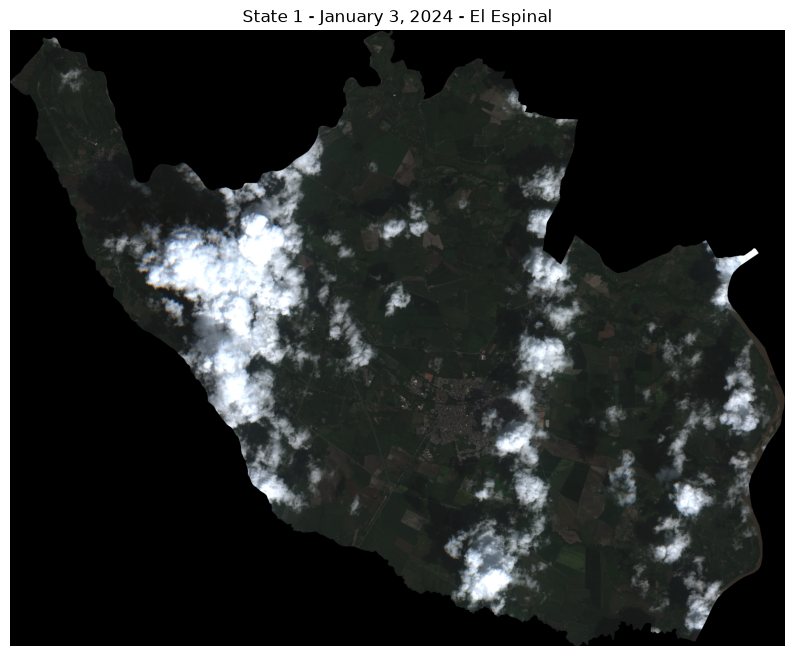

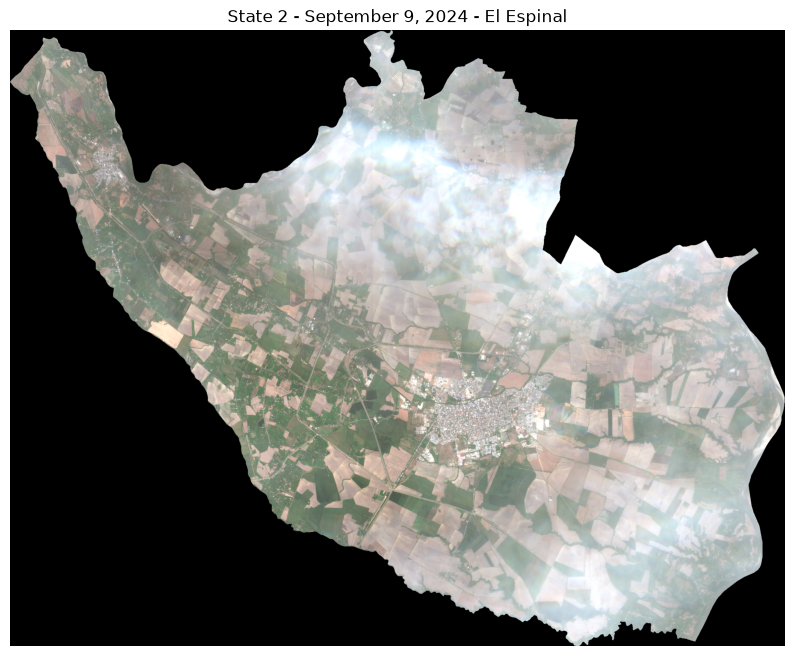

In [57]:
import matplotlib.pyplot as plt


# Function for RGB visualization
def normalize_rgb(rgb, percentile=98):
    
    rgb = rgb.astype("float32")
    
    valid = rgb > 0
    
    if np.any(valid):
        vmax = np.percentile(rgb[valid], percentile)
    else:
        vmax = 1
    
    rgb_norm = np.clip(rgb / vmax, 0, 1)
    
    return rgb_norm


# Normalize both dates independently for visualization
rgb_state1_display = normalize_rgb(rgb_state1)
rgb_state2_display = normalize_rgb(rgb_state2)


# Display State 1
plt.figure(figsize=(10, 8))
plt.imshow(rgb_state1_display)
plt.title("State 1 - January 3, 2024 - El Espinal")
plt.axis("off")
plt.show()


# Display State 2
plt.figure(figsize=(10, 8))
plt.imshow(rgb_state2_display)
plt.title("State 2 - September 9, 2024 - El Espinal")
plt.axis("off")
plt.show()

In [58]:
# Verify spatial alignment between the two acquisition dates

print("STATE 1 CRS:", state1_crs)
print("STATE 2 CRS:", state2_crs)

print("\nSTATE 1 transform:")
print(state1_transform)

print("\nSTATE 2 transform:")
print(state2_transform)

same_crs = state1_crs == state2_crs
same_transform = state1_transform.almost_equals(state2_transform)
same_shape = state1_stack.shape == state2_stack.shape

print("\nSame CRS:", same_crs)
print("Same transform:", same_transform)
print("Same shape:", same_shape)

if same_crs and same_transform and same_shape:
    print("\nThe two temporal states are spatially aligned.")
else:
    print("\nSpatial alignment is required before change analysis.")

STATE 1 CRS: EPSG:32618
STATE 2 CRS: EPSG:32618

STATE 1 transform:
| 10.00, 0.00, 499270.00|
| 0.00,-10.00, 469760.00|
| 0.00, 0.00, 1.00|

STATE 2 transform:
| 10.00, 0.00, 499270.00|
| 0.00,-10.00, 469760.00|
| 0.00, 0.00, 1.00|

Same CRS: True
Same transform: True
Same shape: True

The two temporal states are spatially aligned.


>## 4.3 Multi-Temporal Spectral Change Analysis

>The two Sentinel-2 RGB composites have the same coordinate reference system (EPSG:32618), spatial resolution (10 m), dimensions, and affine transformation. Therefore, no additional spatial reprojection or alignment is required before the pixel-by-pixel comparison.

>Spectral change between State 1 (January 3, 2024) and State 2 (September 9, 2024) is quantified from the Red (B04), Green (B03), and Blue (B02) bands.

>For each pixel, the magnitude of the RGB spectral difference is calculated using the Euclidean distance between the two acquisition dates. Higher values indicate a greater spectral difference between the observations, while lower values indicate greater spectral similarity.

>Because cloud cover, atmospheric conditions, seasonal variation, and surface conditions can influence spectral reflectance, the resulting raster is interpreted as **spectral change magnitude** rather than as a direct classification of land-use or land-cover change.

>### 4.3.1 Valid Pixel Mask

>A valid-data mask is created before calculating spectral differences. Only pixels containing valid RGB observations in both acquisition dates are retained for the multi-temporal comparison.

>This prevents areas outside the municipal boundary or without valid raster information from being interpreted as spectral change.

In [59]:
# Create valid-data masks for both acquisition dates

valid_state1 = np.any(state1_stack > 0, axis=0)
valid_state2 = np.any(state2_stack > 0, axis=0)

# Pixels must contain valid data in both dates
valid_mask = valid_state1 & valid_state2

total_pixels = valid_mask.size
valid_pixels = np.count_nonzero(valid_mask)
valid_percentage = (valid_pixels / total_pixels) * 100

print("Total pixels:", total_pixels)
print("Valid pixels in both dates:", valid_pixels)
print(f"Valid pixels: {valid_percentage:.2f}%")

Total pixels: 3988980
Valid pixels in both dates: 2162801
Valid pixels: 54.22%


>### 4.3.2 RGB Spectral Change Magnitude

>The spectral difference between the two acquisition dates is calculated independently for the Red, Green, and Blue bands.

>The three band differences are then combined using the Euclidean distance to produce a single spectral change magnitude value for each valid pixel.

In [60]:
# Convert arrays to float before subtraction
state1_float = state1_stack.astype(np.float32)
state2_float = state2_stack.astype(np.float32)

# Spectral difference: State 2 - State 1
difference = state2_float - state1_float

# Euclidean RGB spectral change magnitude
change_image = np.sqrt(
    np.sum(difference ** 2, axis=0)
)

# Keep only pixels valid in both acquisition dates
change_image_valid = np.where(
    valid_mask,
    change_image,
    np.nan
)

valid_changes = change_image_valid[valid_mask]

print("Spectral change magnitude calculated successfully.")
print("Difference bands:", difference.shape)
print("Change image:", change_image_valid.shape)

print("\nDescriptive statistics")
print("Minimum:", np.min(valid_changes))
print("Maximum:", np.max(valid_changes))
print("Mean:", np.mean(valid_changes))
print("Standard deviation:", np.std(valid_changes))

Spectral change magnitude calculated successfully.
Difference bands: (3, 1780, 2241)
Change image: (1780, 2241)

Descriptive statistics
Minimum: 5.0990195
Maximum: 31712.186
Mean: 3362.834
Standard deviation: 4293.691


>### 4.3.3 Visualization of Spectral Change Magnitude

>The RGB spectral change magnitude is visualized spatially across the municipality of El Espinal.

>Lower values represent greater spectral similarity between the two acquisition dates, while higher values indicate stronger spectral differences. These differences may result from changes in vegetation, soil conditions, agricultural dynamics, moisture, clouds, shadows, or other atmospheric and surface effects.

>Therefore, the map represents the magnitude of spectral differences between January and September 2024 and should not be interpreted directly as a land-use or land-cover change classification.

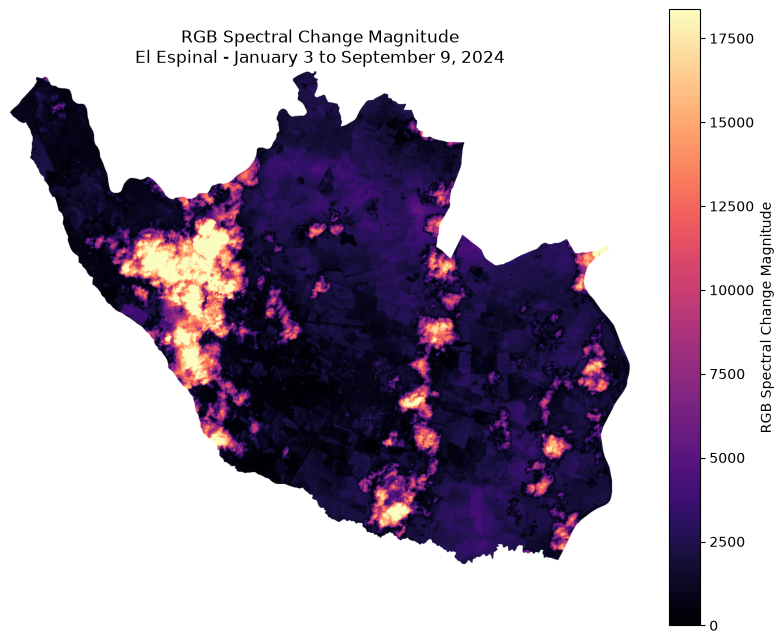

98th percentile used for visualization: 18361.799


In [61]:
# Visualize RGB spectral change magnitude

# Use percentile scaling to reduce the influence of extreme values
vmax_change = np.nanpercentile(change_image_valid, 98)

plt.figure(figsize=(10, 8))

img = plt.imshow(
    change_image_valid,
    cmap="magma",
    vmin=0,
    vmax=vmax_change
)

plt.colorbar(
    img,
    label="RGB Spectral Change Magnitude"
)

plt.title(
    "RGB Spectral Change Magnitude\n"
    "El Espinal - January 3 to September 9, 2024"
)

plt.axis("off")
plt.show()

print("98th percentile used for visualization:", vmax_change)

>### 4.3.4 Change Distribution and Descriptive Statistics

>The distribution of RGB spectral change magnitude is evaluated using the pixels containing valid observations in both acquisition dates.

>The histogram summarizes the frequency and magnitude of spectral differences between January 3 and September 9, 2024. Descriptive statistics are included to characterize the overall distribution.

>High spectral differences may be associated with surface changes as well as differences in cloud cover, atmospheric conditions, vegetation phenology, soil exposure, moisture, and agricultural dynamics. Therefore, the distribution is interpreted as spectral variability between the two observations rather than as a direct measurement of land-cover change.

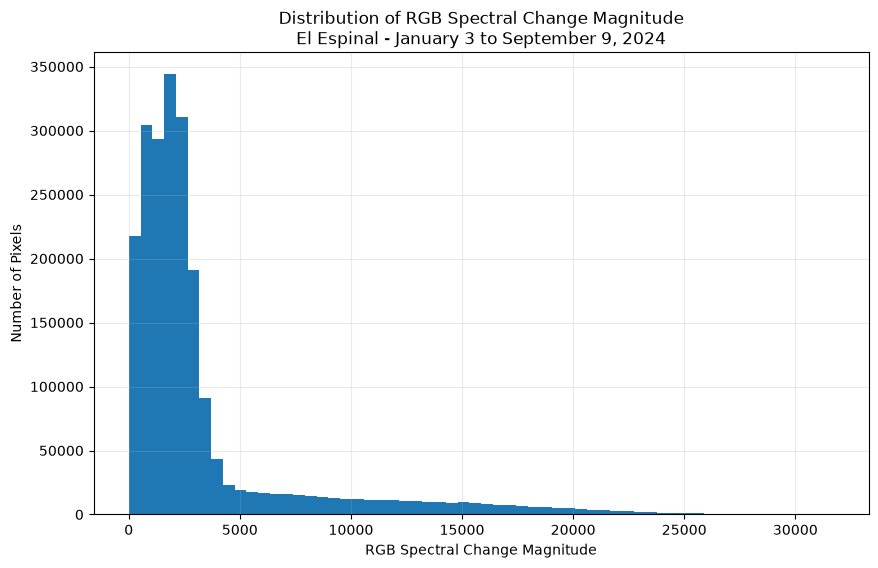

DESCRIPTIVE STATISTICS
Valid pixels: 2,162,801
Minimum: 5.10
Maximum: 31712.19
Mean: 3362.83
Median: 2003.23
Standard deviation: 4293.69
25th percentile: 1093.41
75th percentile: 3036.51
98th percentile: 18361.80


In [62]:
# Distribution of valid RGB spectral change values

plt.figure(figsize=(10, 6))

plt.hist(
    valid_changes,
    bins=60
)

plt.xlabel("RGB Spectral Change Magnitude")
plt.ylabel("Number of Pixels")
plt.title(
    "Distribution of RGB Spectral Change Magnitude\n"
    "El Espinal - January 3 to September 9, 2024"
)

plt.grid(alpha=0.25)
plt.show()


# Descriptive statistics
print("DESCRIPTIVE STATISTICS")
print(f"Valid pixels: {valid_changes.size:,}")
print(f"Minimum: {np.min(valid_changes):.2f}")
print(f"Maximum: {np.max(valid_changes):.2f}")
print(f"Mean: {np.mean(valid_changes):.2f}")
print(f"Median: {np.median(valid_changes):.2f}")
print(f"Standard deviation: {np.std(valid_changes):.2f}")
print(f"25th percentile: {np.percentile(valid_changes, 25):.2f}")
print(f"75th percentile: {np.percentile(valid_changes, 75):.2f}")
print(f"98th percentile: {np.percentile(valid_changes, 98):.2f}")

>## 4.4 Export of the Multi-Temporal Raster Products

>The processed Sentinel-2 data are exported as georeferenced GeoTIFF files to preserve the spatial information required for subsequent visualization and analysis.

>Three raster products are generated:

>- **State 1 RGB:** January 3, 2024.
>- **State 2 RGB:** September 9, 2024.
>- **RGB Spectral Change Magnitude:** pixel-wise spectral difference between the two acquisition dates.

>All products correspond to the complete municipal area of El Espinal and share the same spatial grid, coordinate reference system, and 10 m spatial resolution.

In [63]:
# Export the final multi-temporal raster products as GeoTIFF

import rasterio
import numpy as np

# Output filenames
state1_file = "El_Espinal_State1_RGB_2024-01-03.tif"
state2_file = "El_Espinal_State2_RGB_2024-09-09.tif"
change_file = "El_Espinal_RGB_Spectral_Change_2024.tif"

# ---------------------------------------------------------
# 1. Export State 1 RGB
# ---------------------------------------------------------

with rasterio.open(
    state1_file,
    "w",
    driver="GTiff",
    height=state1_stack.shape[1],
    width=state1_stack.shape[2],
    count=3,
    dtype=state1_stack.dtype,
    crs=state1_crs,
    transform=state1_transform,
    nodata=0
) as dst:
    dst.write(state1_stack)


# ---------------------------------------------------------
# 2. Export State 2 RGB
# ---------------------------------------------------------

with rasterio.open(
    state2_file,
    "w",
    driver="GTiff",
    height=state2_stack.shape[1],
    width=state2_stack.shape[2],
    count=3,
    dtype=state2_stack.dtype,
    crs=state2_crs,
    transform=state2_transform,
    nodata=0
) as dst:
    dst.write(state2_stack)


# ---------------------------------------------------------
# 3. Export RGB spectral change magnitude
# ---------------------------------------------------------

change_export = np.where(
    np.isnan(change_image_valid),
    -9999,
    change_image_valid
).astype(np.float32)

with rasterio.open(
    change_file,
    "w",
    driver="GTiff",
    height=change_export.shape[0],
    width=change_export.shape[1],
    count=1,
    dtype="float32",
    crs=state1_crs,
    transform=state1_transform,
    nodata=-9999
) as dst:
    dst.write(change_export, 1)


# ---------------------------------------------------------
# Verify exported files
# ---------------------------------------------------------

print("GeoTIFF products exported successfully.")

print("\nSTATE 1")
print("File:", state1_file)

print("\nSTATE 2")
print("File:", state2_file)

print("\nSPECTRAL CHANGE")
print("File:", change_file)

print("\nSpatial reference")
print("CRS:", state1_crs)
print("Resolution:", abs(state1_transform.a), "m")
print("Dimensions:", change_export.shape)

GeoTIFF products exported successfully.

STATE 1
File: El_Espinal_State1_RGB_2024-01-03.tif

STATE 2
File: El_Espinal_State2_RGB_2024-09-09.tif

SPECTRAL CHANGE
File: El_Espinal_RGB_Spectral_Change_2024.tif

Spatial reference
CRS: EPSG:32618
Resolution: 10.0 m
Dimensions: (1780, 2241)


>## 4.5 Interactive Visualization with Leafmap

>The final raster products are integrated into an interactive Leafmap visualization to facilitate the spatial and temporal comparison of Sentinel-2 imagery across El Espinal.

>The map contains independent layers for State 1 (January 3, 2024), State 2 (September 9, 2024), the RGB spectral change magnitude, and the municipal boundary of El Espinal.

>The layer control allows the raster products to be activated or deactivated independently, facilitating direct visual comparison between the two acquisition dates and the resulting spectral change magnitude.

In [73]:
import leafmap
import numpy as np

# Create interactive map
m = leafmap.Map()

# State 1 - visible by default
m.add_raster(
    state1_file,
    bands=[1, 2, 3],
    vmin=0,
    vmax=10000,
    nodata=0,
    layer_name="State 1 - January 3, 2024",
    zoom_to_layer=False,
    shown=True
)

# State 2 - initially hidden
m.add_raster(
    state2_file,
    bands=[1, 2, 3],
    vmin=0,
    vmax=10000,
    nodata=0,
    layer_name="State 2 - September 9, 2024",
    zoom_to_layer=False,
    shown=False
)

# Spectral change - initially hidden
change_vmax = float(np.nanpercentile(valid_changes, 98))

m.add_raster(
    change_file,
    colormap="coolwarm",
    vmin=0,
    vmax=change_vmax,
    nodata=-9999,
    layer_name="RGB Spectral Change Magnitude",
    zoom_to_layer=False,
    shown=False
)

# Municipal boundary
m.add_gdf(
    aoi_wgs84,
    layer_name="El Espinal Municipality"
)

# Layer control
m.add_layer_control()

# Explicitly center map on El Espinal
bounds = aoi_wgs84.total_bounds
minx, miny, maxx, maxy = bounds

center_lon = (minx + maxx) / 2
center_lat = (miny + maxy) / 2

m.set_center(
    lon=center_lon,
    lat=center_lat,
    zoom=11
)

m

Map(center=[np.float64(4.16945411150013), np.float64(-74.90565214299991)], controls=(ZoomControl(options=['pos…